# **Modelos de mezcla gaussiana**

## Casos de uso de GMM:

- **Sistemas de recomendación** que ofrecen recomendaciones a los usuarios según las preferencias (como los patrones de consumo de Netflix) de usuarios similares (como vecinos).
- **Detección de anomalías** que identifica elementos, eventos u observaciones inusuales que se desvían significativamente de la mayoría de los datos y no se ajustan a un concepto bien definido de comportamiento normal.
- **Segmentación de clientes** que busca separar a los clientes en múltiples grupos y diseñar una estrategia de marketing específica según las características de cada grupo.

## ¿Cuándo es mejor el GMM que K-Medias?

Imagina que eres un científico de datos que crea un recomendador para vender coches utilizando la agrupación en clústeres K-Medias y tienes dos clústeres. A todos los del clúster A se les recomienda comprar el coche A, que cuesta **100 000** con un margen de beneficio de **25 000**, y a todos los del clúster B se les recomienda comprar el coche B, que cuesta **50 000** con un margen de beneficio de **10 000**.

Supongamos que quieres incluir al mayor número posible de personas en el clúster A, ¿por qué no usar un algoritmo que te informe exactamente de la probabilidad de que alguien esté interesado en comprar el coche A, en lugar de uno que solo te diga un sí o un no rotundo (¡esto es lo que hace K-Medias!)?

Con el GMM, no solo obtendrás las etiquetas de clúster predichas, sino que el algoritmo también te dará la probabilidad de que un punto de datos pertenezca a un clúster. ¡Increíble!

Quienquiera que venda esos autos definitivamente debería desarrollar un mejor plan para un cliente con un 90% de probabilidad de compra que para uno con un 75% de probabilidad, aunque aparezcan en el mismo grupo.

<img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML0187EN-SkillsNetwork/labs/module%201/images/car.png" style="width: 60%">


En este laboratorio, aplicará análisis de agrupamiento en conjuntos de datos multivariados utilizando **modelos de mezcla gaussiana** (GMM).

## __Table of Contents__

<ol>
    <li><a href="#Objectives">Objectives</a></li>
    <li>
        <a href="#Setup">Setup</a>
        <ol>
            <li><a href="#Installing-Required-Libraries">Installing Required Libraries</a></li>
            <li><a href="#Importing-Required-Libraries">Importing Required Libraries</a></li>
            <li><a href="#Defining-Helper-Functions">Defining Helper Functions</a></li>
        </ol>
    </li>
    <li>
        <a href="#What-are-Gaussian-Mixture-Models (GMM)?">What are Gaussian Mixture Models (GMM)?</a>
        <ol>
            <li><a href="#Background">Background</a></li>
            <li><a href="#Playing around with means, standard deviations, and weights">Playing around with means, standard deviations, and weights</a></li>
            <li><a href="#Introducing sklearn.mixture.GaussianMixture">Introducing sklearn.mixture.GaussianMixture</a></li>
            <li><a href="#GMM.predict_proba">GMM.predict_proba</a></li>
        </ol>
    </li>
    <li>
        <a href="#Example 1: Applying GMM on a 2d dataset">Example 1: Applying GMM on a 2d dataset</a>
        <ol>
            <li><a href="#Generate an artificial 2d Gaussian mixture data">Generate an artificial 2d Gaussian mixture data</a></li>
            <li><a href="#Fit a GMM">Fit a GMM</a></li>
            <li><a href="#Plot the clusters">Plot the clusters</a></li>
            <li><a href="#Try different values of Covariance_type">Try different values of Covariance_type</a></li>          
        </ol>   
    </li>
    <li>
        <a href="#Example 2: Applying GMM on real world data - Image Segmentation">Example 2: Applying GMM on real world data - Image Segmentation</a>
    </li>
</ol>

<a href="#Exercises">Exercises</a>
<ol>
    <li><a href="#Exercise 1 - Scale the data (using StandardScaler)">Exercise 1 - Scale the data (using StandardScaler)</a></li>
    <li><a href="#Exercise 2 - Use PCA with n_components=2 for dimension reduction">Exercise 2 - Use PCA with n_components=2 for dimension reduction</a></li>
    <li><a href="#Exercise 3 - Fit a GMM to the reduced data ">Exercise 3 - Fit a GMM to the reduced data</a></li>
    <li><a href="#Exercise 4 - Output the predicted labels for visualizing clusters">Exercise 4 - Output the predicted labels for visualizing clusters</a></li>
    <li><a href="#Exercise 5 - Clustering and visualizing using 3 principal components (OPTIONAL)">Exercise 5 - Clustering and visualizing using 3 principal components (OPTIONAL)</a></li>
</ol>

## Objetivos

Después de completar este laboratorio, usted podrá:

- __Comprender__ qué es la mezcla gaussiana y cómo sus parámetros de distribución afectan las probabilidades a priori.
- __Comprender__ qué es el modelo de mezcla gaussiana y cómo funciona como técnica de agrupamiento.
- __Aplicar__ el GMM eficazmente.

## Setup


Para este laboratorio, utilizaremos las siguientes bibliotecas:
-* [`pandas`](https://pandas.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) para la gestión de dato
- * [`numpy`](https://numpy.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) para operaciones matemática
-  * [`sklearn`](https://scikit-learn.org/stable/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) para funciones relacionadas con el aprendizaje automático y su canalizació
- * [`seaborn`](https://seaborn.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) para visualizar los dato
- * [`matplotlib`](https://matplotlib.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) para herramientas de gráficos adicionales.


# Instalación de las bibliotecas necesarias

Las siguientes bibliotecas necesarias están preinstaladas en el entorno de Skills Network Labs. Sin embargo, si ejecuta estos comandos de notebook en un entorno Jupyter diferente (p. ej., Watson Studio o Anaconda), deberá instalarlas eliminando el símbolo "#" antes de "!mamba" en la celda de código a continuación.

In [1]:
# All Libraries required for this lab are listed below. The libraries pre-installed on Skills Network Labs are commented.
# !mamba install -qy pandas==1.3.4 numpy==1.21.4 seaborn==0.9.0 matplotlib==3.5.0 scikit-learn==0.20.1 wget
# Note: If your environment doesn't support "!mamba install", use "!pip install pandas==1.3.4 ..."

### Importación de las bibliotecas necesarias

Le recomendamos importar todas las bibliotecas necesarias en un solo lugar (aquí):


In [3]:
# You can also use this section to suppress warnings generated by your code:
# Puedes usar esta sección para suprimir (ocultar) advertencias generadas por el código
import warnings
warnings.filterwarnings('ignore')  # Ignora todos los warnings para que no se muestren

# =============================
# Importación de librerías
# =============================

import numpy as np              # Operaciones numéricas y manejo de arreglos
import pandas as pd             # Manejo y análisis de datos en tablas (DataFrames)
import scipy.stats as ss        # Funciones estadísticas
import matplotlib.pyplot as plt # Visualización de gráficos


from sklearn.mixture import GaussianMixture  # Modelo de mezcla de gaussianas (GMM)
import seaborn as sns            # Librería de visualización estadística

from sklearn.preprocessing import StandardScaler  # Estandarización de variables
from scipy.stats import multivariate_normal       # Distribución normal multivariada
from itertools import chain                       # Herramientas para trabajar con iterables
from matplotlib.patches import Ellipse             # Dibujar elipses en gráficas

# =============================
# Configuración visual de Seaborn
# =============================

sns.set_context('notebook')  # Tamaños de gráficos optimizados para Jupyter Notebook
sns.set_style('white')       # Estilo limpio con fondo blanco

# =============================
# Función para anular warnings
# =============================

def warn(*args, **kwargs):
    pass  # Función vacía que no hace nada


### Definición de funciones auxiliares

Utilice esta sección para definir las funciones auxiliares que mejoren la legibilidad del código del notebook:


In [5]:
# Esta función permite simular y graficar una mezcla Gaussiana univariada (1D)
# Recibe medias, desviaciones estándar, pesos y el número de muestras
def plot_univariate_mixture(means, stds, weights, N=10000, seed=10):
    
    """
    Regresa:
    - X: dataset simulado en 1D
    - fig: figura de matplotlib
    - ax: eje de la figura
    """
    
    np.random.seed(seed)  # Fija la semilla para reproducibilidad
    
    # Verifica que medias, desviaciones y pesos tengan la misma longitud
    if not len(means) == len(stds) == len(weights):
        raise Exception("Length of mean, std, and weights don't match.") 
    
    K = len(means)  # Número de componentes Gaussianos
    
    # Selecciona aleatoriamente qué Gaussiana genera cada punto según los pesos
    mixture_idx = np.random.choice(K, size=N, replace=True, p=weights)
    
    # Genera N valores siguiendo la mezcla Gaussiana
    X = np.fromiter(
        (ss.norm.rvs(loc=means[i], scale=stds[i]) for i in mixture_idx),
        dtype=np.float64
    )
      
    # Genera valores para el eje X del gráfico
    xs = np.linspace(X.min(), X.max(), 300)
    ps = np.zeros_like(xs)  # Inicializa la PDF total
    
    # Calcula la PDF de la mezcla como suma ponderada de PDFs Gaussianas
    for mu, s, w in zip(means, stds, weights):
        ps += ss.norm.pdf(xs, loc=mu, scale=s) * w
    
    # Crea la figura y el eje
    fig, ax = plt.subplots()
    ax.plot(xs, ps, label='pdf of the Gaussian mixture')
    ax.set_xlabel("X", fontsize=15)
    ax.set_ylabel("P", fontsize=15)
    ax.set_title("Univariate Gaussian mixture", fontsize=15)
    
    # Devuelve X en forma columna para compatibilidad con sklearn
    return X.reshape(-1, 1), fig, ax


# ======================================================
# Función para simular y graficar una mezcla Gaussiana 2D
# ======================================================
def plot_bivariate_mixture(means, covs, weights, N=10000, seed=10):
    
    """
    Regresa:
    - X: dataset simulado en 2D
    - Muestra un scatter plot del conjunto de datos
    """
    
    np.random.seed(seed)  # Semilla para reproducibilidad
    
    # Verifica consistencia en tamaños
    if not len(means) == len(covs) == len(weights):
        raise Exception("Length of mean, cov, and weights don't match.") 
    
    K = len(means)      # Número de Gaussianas
    M = len(means[0])   # Dimensión (2D)
    
    # Selecciona el componente Gaussiano para cada muestra
    mixture_idx = np.random.choice(K, size=N, replace=True, p=weights)
    
    # Genera N observaciones de la mezcla Gaussiana multivariada
    X = np.fromiter(
        chain.from_iterable(
            multivariate_normal.rvs(mean=means[i], cov=covs[i])
            for i in mixture_idx
        ),
        dtype=float
    )
    
    # Ajusta la forma del arreglo a (N, M)
    X.shape = N, M
    
    # Extrae las dimensiones
    xs1 = X[:, 0]
    xs2 = X[:, 1]
    
    # Gráfico de dispersión de los datos
    plt.scatter(xs1, xs2, label="data")
    
    # Grafica las medias de cada componente
    L = len(means)
    for l, pair in enumerate(means):
        plt.scatter(pair[0], pair[1], color='red')
        if l == L - 1:
            break
    
    # Etiqueta la última media
    plt.scatter(pair[0], pair[1], color='red', label="mean")
    
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")
    plt.title("Scatter plot of the bivariate Gaussian mixture")
    plt.legend()
    plt.show()
    
    return X


# ======================================================
# Función para dibujar elipses de covarianza
# ======================================================
def draw_ellipse(position, covariance, ax=None, **kwargs):
    
    """
    Dibuja una elipse dada una posición (media) y una matriz de covarianza
    """
    
    ax = ax or plt.gca()  # Usa el eje actual si no se pasa uno
    
    # Convierte la covarianza a ejes principales
    if covariance.shape == (2, 2):
        # Descomposición SVD para obtener orientación y escala
        U, s, Vt = np.linalg.svd(covariance)
        angle = np.degrees(np.arctan2(U[1, 0], U[0, 0]))  # Ángulo de rotación
        width, height = 2 * np.sqrt(s)  # Tamaños de la elipse
    else:
        # Caso diagonal (varianzas independientes)
        angle = 0
        width, height = 2 * np.sqrt(covariance)
    
    # Dibuja elipses para 1, 2 y 3 desviaciones estándar
    for nsig in range(1, 4):
        ax.add_patch(
            Ellipse(position, nsig * width, nsig * height, angle=angle, **kwargs)

        )


# ======================================================
# Función para visualizar un modelo GMM ajustado
# ======================================================
def plot_gmm(gmm, X, label=True, ax=None):
    
    # Usa el eje actual si no se proporciona uno
    ax = ax or plt.gca()
    
    # Ajusta el modelo GMM y obtiene las etiquetas de clúster
    labels = gmm.fit(X).predict(X)
    
    # Grafica los puntos del dataset
    if label:
        ax.scatter(
            X[:, 0], X[:, 1],
            c=labels, s=40,
            cmap='viridis', zorder=2
        )
    else:
        ax.scatter(
            X[:, 0], X[:, 1],
            s=40, zorder=2
        )
    
    # Mantiene la misma escala en ambos ejes
    ax.axis('equal')
    
    # Factor de escala para el tamaño de las elipses
    w_factor = 0.2 / gmm.weights_.max()
    
    # Dibuja una elipse por cada componente Gaussiano
    for pos, covar, w in zip(
        gmm.means_,
        gmm.covariances_,
        gmm.weights_
    ):
        draw_ellipse(
            pos,
            covar,
            ax=ax,                 # ← PASA EL AX EXPLÍCITAMENTE
            alpha=w * w_factor     # Transparencia proporcional al peso
        )



## ¿Qué son los Modelos de Mezcla Gaussiana (MGM)?

En resumen, los Modelos de Mezcla Gaussiana (MGM) son un algoritmo de agrupamiento que:

- Ajusta una combinación ponderada de distribuciones gaussianas a sus datos.
- El científico de datos (usted) debe determinar el número de distribuciones gaussianas («k»).


<p style='color: blue'>Agrupamiento duro vs. agrupamiento blando:</p>

- Los algoritmos de __agrupamiento duro__ asignan cada punto de datos a exactamente un clúster.
- Los algoritmos de __agrupamiento blando__ devuelven las probabilidades de que cada punto de datos pertenezca a todos los `k` clústeres.

_GMM es un algoritmo de agrupamiento blando._


### Background


Una mezcla gaussiana es una combinación ponderada de (`k`) gaussianas, donde cada una se identifica mediante los siguientes parámetros:

1. Un vector de media $\boldsymbol{\mu}_i$
2. Una matriz de covarianza $\boldsymbol{\Sigma}_i$
3. Un peso del componente $\pi_i$ que indica la contribución de la $i$ésima gaussiana

En conjunto, la función de densidad de probabilidad (fdp) del modelo de mezcla se formula como:

$$
p(\boldsymbol{x}) = \sum_{i=1}^K\pi_i \mathcal{N}(x|\boldsymbol{\mu_i,\Sigma_i}), \\\\\\ \sum_{i=1}^K\pi_i = 1
$$

Antes de comenzar a aplicar el modelo en un entorno multivariante, profundicemos en los tres parámetros y veamos cómo la modificación de sus valores afecta la apariencia de la mezcla gaussiana en una dimensión inferior. Usaremos la función auxiliar **plot_univariate_mixture** para representar gráficamente la mezcla de forma eficiente.


### Experimentando con medias, desviaciones típicas y ponderaciones

Comencemos con una mezcla de tres gaussianas univariadas con:
- medias iguales a **2, 5, 8** respectivamente
- desviación típica igual a **0,2, 0,5, 0,8** respectivamente
- ponderación del componente igual a **0,3, 0,3, 0,4** respectivamente


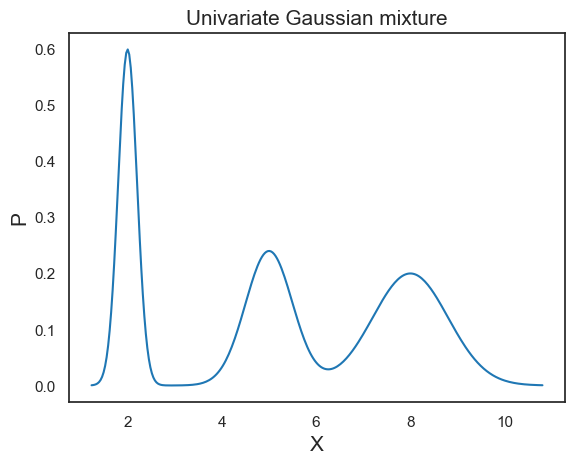

In [7]:
# Genera y grafica una mezcla Gaussiana univariada (1D)
# means: medias de cada componente Gaussiano
# stds: desviación estándar de cada componente
# weights: peso (probabilidad) de cada Gaussiana en la mezcla
# La suma de los weights debe ser 1
X1, fig1, ax1 = plot_univariate_mixture(
    means=[2, 5, 8],        # Centros de las tres distribuciones Gaussianas
    stds=[0.2, 0.5, 0.8],   # Dispersión de cada Gaussiana
    weights=[0.3, 0.3, 0.4] # Proporción de datos generados por cada Gaussiana
)


Los picos en el gráfico de distribución (pdf) anterior se encuentran alrededor de x = 2, 5, 8, que son las medias de nuestras gaussianas.

- **Si aumentamos el valor de las desviaciones estándar**, observaremos que las formas de campana se ensanchan y que habrá superposiciones entre dos gaussianas.

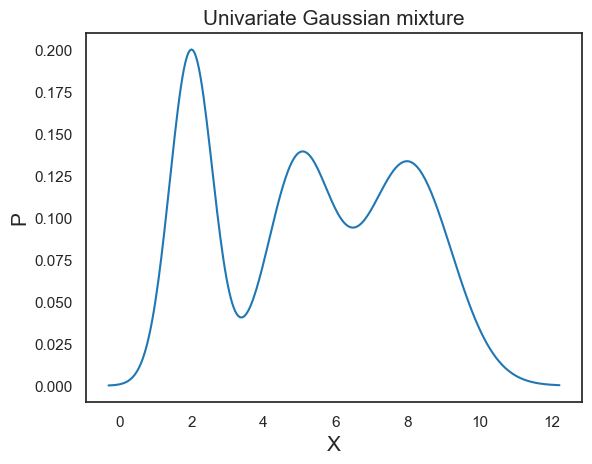

In [9]:
# Genera y grafica una mezcla Gaussiana univariada (1D)
# En este caso, las Gaussianas tienen MAYOR desviación estándar,
# por lo que las distribuciones son más anchas y se traslapan más
X2, fig2, ax2 = plot_univariate_mixture(
    means=[2, 5, 8],         # Medias de las tres Gaussianas (mismos centros)
    stds=[0.6, 0.9, 1.2],    # Desviaciones estándar más grandes (mayor dispersión)
    weights=[0.3, 0.3, 0.4]  # Pesos de cada componente (suman 1)
)


Manteniendo las medias y las desviaciones estándar sin cambios.
- Cambiemos los pesos de las gaussianas y veamos cómo afecta la distribución de la mezcla.

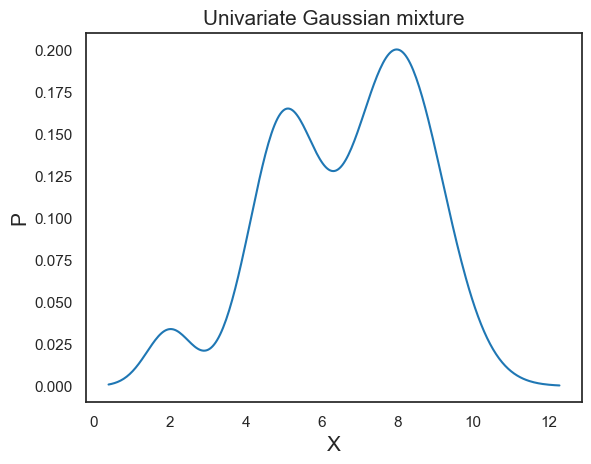

In [14]:
# Genera y grafica una mezcla Gaussiana univariada (1D)
# En este caso se mantienen las mismas medias y desviaciones estándar,
# pero se cambian los pesos, alterando la proporción de datos por componente
X3, fig3, ax3 = plot_univariate_mixture(
    means=[2, 5, 8],          # Medias de las Gaussianas (centros fijos)
    stds=[0.6, 0.9, 1.2],     # Desviaciones estándar (misma dispersión)
    weights=[0.05, 0.35, 0.6] # Pesos distintos: una Gaussiana domina la mezcla
)


- **Al reducir o aumentar el peso de una gaussiana, la probabilidad de ver un punto de esa gaussiana también disminuye o aumenta**, como se ilustra en el gráfico de distribución anterior.

En conclusión:
- Las **medias** determinan los centros de las gaussianas mixtas.
- Las matrices de **covarianza** determinan la anchura y la forma de las gaussianas mixtas.
- Los **pesos** determinan las contribuciones de las gaussianas a la mezcla gaussiana.


### Introducción sklearn.mixture.GaussianMixture


Con los datos generados de la mezcla gaussiana, conocemos de antemano los valores de los parámetros de cada gaussiana. Al encontrar un conjunto de datos reales, ¿cómo sabemos el número de gaussianas que se incluirán en el modelo de mezcla y sus valores de parámetros correspondientes?

- Podemos utilizar la clase **GaussianMixture** de **Scikit-learn**. Esta clase nos permite estimar los parámetros de una distribución de mezcla gaussiana.

- Se proporciona un método **GaussianMixture.fit** que aprende un Modelo de Mezcla Gaussiana a partir de los datos de entrenamiento. Dados los datos de prueba, puede asignar a cada muestra la gaussiana a la que probablemente pertenece mediante el método **GaussianMixture.predict**.

- Para calcular los parámetros del GMM, se implementa el algoritmo **EM ((Expectation–Maximization)**. **E** significa **Expectativa** y **M** significa **Maximización**. El algoritmo funciona alternando entre un paso **E**, que calcula la expectativa de la verosimilitud logarítmica de observar el conjunto de datos utilizando las estimaciones de los parámetros actuales, y un paso **M**, que busca nuevas estimaciones de los parámetros que maximicen la expectativa encontrada en el paso E anterior. Este proceso se repite hasta la convergencia.

Para obtener información más detallada sobre el **algoritmo EM**, consulte la página: <a href="https://en.wikipedia.org/wiki/Expectation%E2%80%93maximization_algorithm?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork821-2023-01-01"> Enlace EM</a>

### GMM.predict_proba


- Un parámetro que debe especificarse al implementar un GMM es `n_components`, que indica al algoritmo cuántos clústeres buscar en el conjunto de datos. Otro parámetro que debe considerarse es `covariance_type`, que abordaremos más adelante con un conjunto de datos multivariante.

A partir de **X1**, el conjunto de datos univariados que generamos antes de usar **plot_univariate_mixture**, podemos ajustar un GMM con `n_components = 3` y representar gráficamente las probabilidades previas predichas de cada punto perteneciente a los tres clústeres. **GMM.predict_proba_** evalúa la densidad de los componentes para cada muestra o, para la muestra $x_n$, la probabilidad $p(i|x_{n})$.

Ordena X1 de menor a mayor para facilitar la visualización de las probabilidades

In [38]:
X1_sorted = np.sort(X1.reshape(-1)).reshape(-1, 1)# reshape(-1) lo convierte a vector 1D y luego se regresa a forma columna
X1_sorted

array([[ 1.23499301],
       [ 1.30528665],
       [ 1.32288788],
       ...,
       [10.73576351],
       [10.80103723],
       [10.80264687]])

 Crea un modelo de Mezcla Gaussiana con 3 componentes

In [23]:
GMM = GaussianMixture(n_components=3, random_state=10)
GMM

GaussianMixture(n_components=3, random_state=10)

Ajusta el modelo a los datos ordenados

In [33]:
GMM.fit(X1_sorted)

GaussianMixture(n_components=3, random_state=10)

Calcula la probabilidad de que cada punto pertenezca a cada uno de los 3 clústeres

In [35]:
prob_X1 = GMM.predict_proba(X1_sorted)
prob_X1

array([[4.66656315e-14, 1.00000000e+00, 2.76439352e-10],
       [2.84215020e-14, 1.00000000e+00, 2.22759731e-10],
       [2.55491932e-14, 1.00000000e+00, 2.14401136e-10],
       ...,
       [1.00000000e+00, 0.00000000e+00, 5.81197021e-26],
       [1.00000000e+00, 0.00000000e+00, 1.77148185e-26],
       [1.00000000e+00, 0.00000000e+00, 1.72011662e-26]])

Gráficas de probabilidades

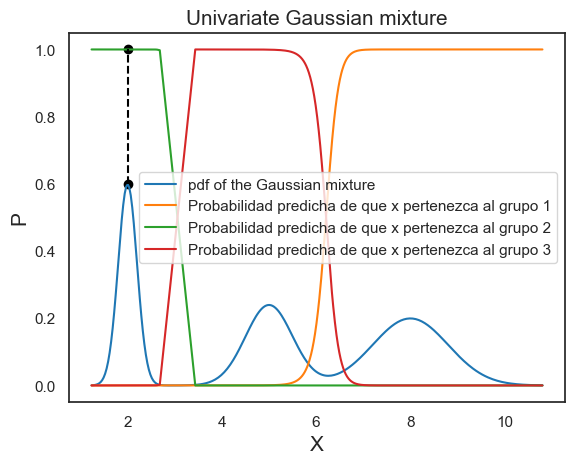

In [42]:
# Grafica la probabilidad predicha de pertenecer a cada clúster
ax1.plot(X1_sorted, prob_X1[:, 0],
         label='Probabilidad predicha de que x pertenezca al grupo 1')
ax1.plot(X1_sorted, prob_X1[:, 1],
         label='Probabilidad predicha de que x pertenezca al grupo 2')
ax1.plot(X1_sorted, prob_X1[:, 2],
         label='Probabilidad predicha de que x pertenezca al grupo 3')

# Marca puntos específicos en x = 2 para análisis visual
ax1.scatter(2, 0.6, color='black')  # Punto inferior
ax1.scatter(2, 1.0, color='black')  # Punto superior

# Dibuja una línea vertical discontinua en x = 2
ax1.plot([2, 2], [0.6, 1.0], '--', color='black')

# Muestra la leyenda del gráfico
ax1.legend()

# Muestra la figura final
fig1


**Código completo**

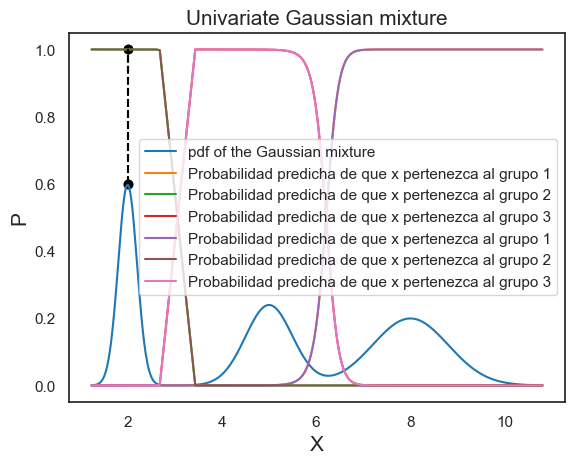

In [45]:
# Ordena X1 de menor a mayor para facilitar la visualización de las probabilidades
# reshape(-1) lo convierte a vector 1D y luego se regresa a forma columna
X1_sorted = np.sort(X1.reshape(-1)).reshape(-1, 1)

# =============================
# Ajuste del modelo GMM
# =============================

# Crea un modelo de Mezcla Gaussiana con 3 componentes
GMM = GaussianMixture(n_components=3, random_state=10)

# Ajusta el modelo a los datos ordenados
GMM.fit(X1_sorted)

# =============================
# Predicción de probabilidades
# =============================

# Calcula la probabilidad de que cada punto pertenezca
# a cada uno de los 3 clústeres
prob_X1 = GMM.predict_proba(X1_sorted)

# =============================
# Gráficas de probabilidades
# =============================

# Grafica la probabilidad predicha de pertenecer a cada clúster
ax1.plot(X1_sorted, prob_X1[:, 0],
         label='Probabilidad predicha de que x pertenezca al grupo 1')
ax1.plot(X1_sorted, prob_X1[:, 1],
         label='Probabilidad predicha de que x pertenezca al grupo 2')
ax1.plot(X1_sorted, prob_X1[:, 2],
         label='Probabilidad predicha de que x pertenezca al grupo 3')

# Marca puntos específicos en x = 2 para análisis visual
ax1.scatter(2, 0.6, color='black')  # Punto inferior
ax1.scatter(2, 1.0, color='black')  # Punto superior

# Dibuja una línea vertical discontinua en x = 2
ax1.plot([2, 2], [0.6, 1.0], '--', color='black')

# Muestra la leyenda del gráfico
ax1.legend()

# Muestra la figura final
fig1


Para interpretar las probabilidades predichas, observemos el punto coloreado en negro, como ejemplo. 
En la **función de densidad de probabilidad (fdp)** de la mezcla gaussiana, el punto se encuentra en el pico de la primera curva en forma de campana. Su probabilidad correspondiente de pertenecer al grupo 1 es igual a 1, lo que demuestra que la probabilidad de que el centro de una distribución gaussiana pertenezca a su propio grupo es del 100 %.


## Ejemplo 1: Aplicación de GMM en un conjunto de datos 2D

### Generar datos de mezcla gaussiana 2D artificiales

Utilizaremos la función auxiliar **plot_bivariate_mixture** para generar primero un conjunto de datos de mezcla gaussiana 2D y luego visualizar los puntos de datos.

**Definición de parámetros para la mezcla Gaussiana**
- Medias de las tres Gaussianas (centros en $2$D)

In [49]:
mean = [(1, 5), (2, 1), (6, 2)] # Cada tupla representa (x1, x2)
mean

[(1, 5), (2, 1), (6, 2)]

**MATRICES DE COVARIANZA $\sum $**

Cada matriz 2x2 define:
- La varianza en cada variable (diagonal principsl)
- La correlación entre variables (valores fuera de la diagonal)

Esto determina la forma, tamaño y orientación del cluster (elipse).

- Matriz de covarianza de los 3 componentes Gaussiano. Controla la dispersión y correlación entre $x_1$ y $x_2$

In [69]:
cov1 = np.array([[0.5, 0.3],   # 0.5 = varianza en x1 | 0.3 = correlación x1-x2
                 [0.3, 0.8]])  # 0.8 = varianza en x2
cov1 

array([[0.5, 0.3],
       [0.3, 0.8]])

In [71]:
cov2 = np.array([[0.8, 0.4],
                 [0.4, 1.2]])
cov2

array([[0.8, 0.4],
       [0.4, 1.2]])

In [73]:
cov3 = np.array([[1.2, 0.5],  # Alta varianza en x1
                 [0.5, 0.9]])
cov3

array([[1.2, 0.5],
       [0.5, 0.9]])

Lista con todas las matrices de covarianza

In [75]:
cov = [cov1, cov2, cov3]
cov

[array([[0.5, 0.3],
        [0.3, 0.8]]),
 array([[0.8, 0.4],
        [0.4, 1.2]]),
 array([[1.2, 0.5],
        [0.5, 0.9]])]

**Pesos de la mezcla**
- Pesos asociados a cada componente Gaussiano.
- Representan la probabilidad previa de que un punto pertenezca a cada cluster.
- Deben cumplir:  ($\sum \pi_k$) = 1

In [96]:
weights = [0.3, 0.3, 0.4]

**Interpretación:**
- 30% de los datos provendrán de la Gaussiana 1.
- 30% de los datos provendrán de la Gaussiana 2.
- 40% de los datos provendrán de la Gaussiana 3.
  
El tercer cluster será ligeramente más grande

**Generación y visualización del dataset 2D** 

Se genera un conjunto de datos bidimensional (2D) utilizando los parámetros definidos previamente:
- means: centros ($\mu _k$)
- covs: matrices de covarianza ($\sum _k$)
- weights: proporciones de cada componente ($\pi _k$)
- N: número total de puntos a simular


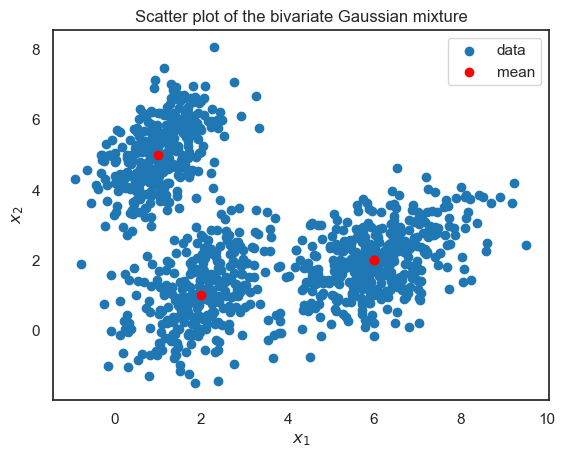

In [98]:
X4 = plot_bivariate_mixture(
    means=mean,      # Lista de medias de cada componente
    covs=cov,        # Lista de matrices de covarianza
    weights=weights, # Pesos de mezcla (π_k)
    N=1000           # Total de observaciones generadas
)


El resultado: X4 contiene 1000 puntos generados a partir de una mezcla de 3 distribuciones normales.

La cantidad de puntos por cluster será aproximadamente:
- 300 del componente 1
- 300 del componente 2
- 400 del componente 3

Visualmente se observarán tres elipses con diferente tamaño, forma y densidad, de acuerdo con sus covarianzas y pesos.

**Código completo**

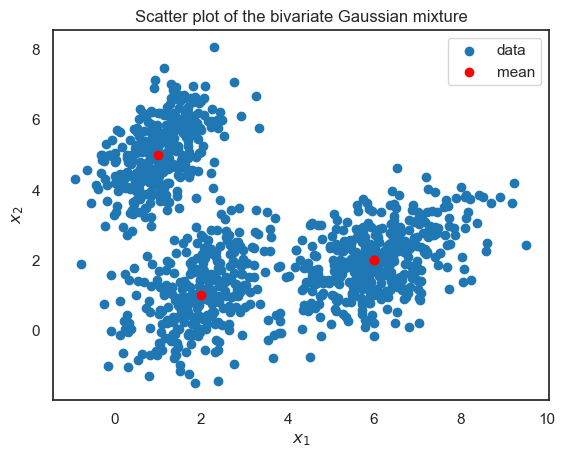

In [104]:
# ============================================
# Definición de parámetros para la mezcla Gaussiana
# ============================================

# Medias de las tres Gaussianas (centros en 2D)
# Cada tupla representa (x1, x2)
mean = [(1, 5), (2, 1), (6, 2)]

# Matriz de covarianza del primer componente Gaussiano
# Controla la dispersión y correlación entre x1 y x2
cov1 = np.array([[0.5, 0.3],
                 [0.3, 0.8]])

cov2 = np.array([[0.8, 0.4],
                 [0.4, 1.2]])

cov3 = np.array([[1.2, 0.5],
                 [0.5, 0.9]])


# Lista con todas las matrices de covarianza
cov = [cov1, cov2, cov3]

# Pesos de cada Gaussiana en la mezcla (deben sumar 1)
weights = [0.3, 0.3, 0.4]

# ============================================
# Generación y visualización del dataset 2D
# ============================================

# Genera un conjunto de datos bivariado (2D) a partir de la mezcla Gaussiana
# N indica el número total de puntos simulados
X4 = plot_bivariate_mixture(
    means=mean,
    covs=cov,
    weights=weights,
    N=1000
)
                  

Para trabajar con el GMM, podemos usar la función **GaussianMixture** de **sklearn.mixture**. Esta función ajustará un GMM a nuestros datos y devolverá el resultado de la agrupación, que incluye los valores de los parámetros que mencionamos.

In [106]:
print("El conjunto de datos que generamos tiene una forma de ", X4.shape)

El conjunto de datos que generamos tiene una forma de  (1000, 2)


### Fit a GMM


X4 es el **dataset generado previamente con la mezcla Gaussiana**

In [116]:
X4 

array([[5.12999475, 0.8649074 ],
       [0.18940021, 2.93879735],
       [5.96673637, 2.17199141],
       ...,
       [1.184349  , 5.84741451],
       [7.12126513, 2.77186522],
       [0.39178308, 4.83188761]])

- Como el dataset X4 fue generado a partir de una mezcla de 3 Gaussianas, tiene sentido ajustar un modelo GMM con n_components = 3

In [119]:
gm = GaussianMixture(
    n_components=3,   # Número de componentes (Gaussianas) del modelo
    random_state=0    # Semilla para reproducibilidad
).fit(X4)             # Ajusta el modelo a los datos X4
gm

GaussianMixture(n_components=3, random_state=0)

Las medias estimadas por el modelo **gm** 

In [122]:
print(gm.means_)

[[1.03433288 5.03638513]
 [6.06270843 1.98414762]
 [1.95897382 1.0795212 ]]


**Cógigo completo**

In [124]:
gm = GaussianMixture(
    n_components=3,   # Número de componentes (Gaussianas) del modelo
    random_state=0    # Semilla para reproducibilidad
).fit(X4)             # Ajusta el modelo a los datos X4

# Imprime un mensaje descriptivo
print("Las medias de las 3 gaussianas ajustadas por GMM son\n")

# Muestra las medias estimadas por el modelo GMM
# Cada fila corresponde al centro (media) de una Gaussiana en 2D
print(gm.means_)


Las medias de las 3 gaussianas ajustadas por GMM son

[[1.03433288 5.03638513]
 [6.06270843 1.98414762]
 [1.95897382 1.0795212 ]]


In [127]:
print("Las covarianzas de las 3 gaussianas ajustadas por GMM son")
gm.covariances_

Las covarianzas de las 3 gaussianas ajustadas por GMM son


array([[[0.49701446, 0.3514976 ],
        [0.3514976 , 0.92502377]],

       [[1.16364816, 0.49962662],
        [0.49962662, 0.90667907]],

       [[0.71099154, 0.38579315],
        [0.38579315, 1.14537899]]])

Los tres centros que arroja nuestro GMM ajustado se aproximan mucho a los valores medios que establecimos para generar los datos de la mezcla, lo que significa que el ajuste del modelo fue bastante exitoso.

También podemos dibujar las tres elipses, utilizando los valores de los parámetros ajustados, para comprobar si realmente representan los tres clústeres de los datos generados.

### Plot the clusters


Utilizaremos las funciones auxiliares **draw_ellipse** y **plot_gmm** para trazar el diagrama de dispersión original, así como los grupos producidos por un GMM ajustado.

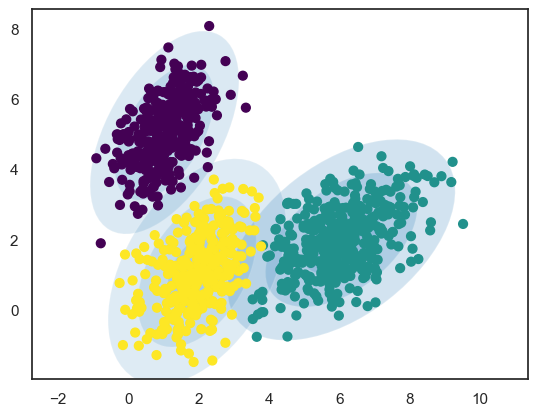

In [129]:
# Visualiza el ajuste de un modelo GMM sobre los datos simulados X4
plot_gmm(
    GaussianMixture(n_components=3, random_state=0),  # Modelo GMM con 3 Gaussianas
    X4                                                # Datos 2D de la mezcla simulada
)


### Pruebe diferentes valores de Covariance_type

Para la función **sklearn.mixture.GaussianMixture**, no solo podemos especificar el número de clústeres que queremos que ajuste el GMM, sino también el tipo de parámetros de covarianza a utilizar (recuerde que comentamos que las matrices de **covarianza** determinan la forma de nuestras gaussianas). Dependiendo del conjunto de datos (cada conjunto de datos tiene diferentes estructuras de mezcla gaussiana), hay 4 valores que puede probar para **Covariance_type**:

- `full`: cada componente tiene su propia matriz de covarianza general.
- `tied`: todos los componentes comparten la misma matriz de covarianza general.
- `diag`: cada componente tiene su propia matriz de covarianza diagonal.
- `spherical`: cada componente tiene su propia varianza única.

_El **Covariance_type** predeterminado en **sklearn.mixture.GaussianMixture** es `full`._

**A veces no se puede usar covariance_type = full, porque no se puede invertir y esto le dará un error.**

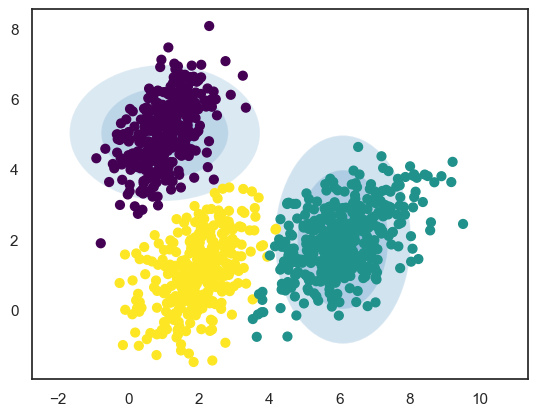

In [131]:
# Prueba un modelo GMM usando covariance_type = 'tied'
# En este caso, TODAS las Gaussianas comparten la misma matriz de covarianza
plot_gmm(
    GaussianMixture(
        n_components=3,        # Número de componentes Gaussianos
        covariance_type='tied',# Una sola covarianza compartida por todos los clústeres
        random_state=0         # Semilla para reproducibilidad
    ),
    X4                         # Datos simulados de la mezcla Gaussiana 2D
)


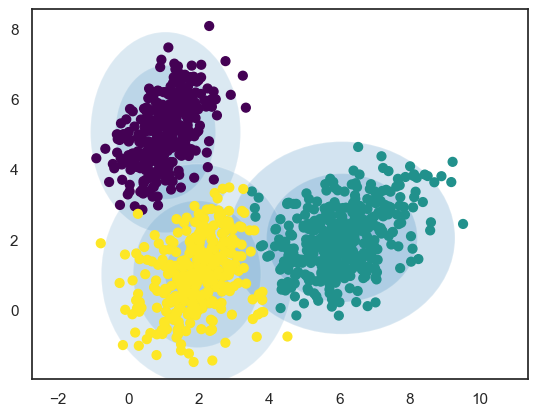

In [133]:
# Prueba un modelo GMM usando covariance_type = 'diag'
# Cada Gaussiana tiene su propia covarianza, pero SOLO en la diagonal
# (no se permite correlación entre x1 y x2)
plot_gmm(
    GaussianMixture(
        n_components=3,        # Número de componentes Gaussianos
        covariance_type='diag',# Covarianzas diagonales por clúster
        random_state=0         # Semilla para reproducibilidad
    ),
    X4                         # Datos simulados de la mezcla Gaussiana 2D
)


Visualmente, es evidente que **covariance_type =** `full` es una buena opción para los datos generados. Esto tiene sentido, ya que, intencionalmente, asignamos a cada gaussiana su propia matriz de covarianza.

Ahora que sabemos cómo trabajar con GMM en una dimensión inferior (2d), podemos importar un conjunto de datos reales y usar GMM para realizar un análisis de agrupamiento.

##  Ejemplo 2: Aplicación de GMM a datos del mundo real: Segmentación de imágenes

Image segmentation is the process of segmenting an image into multiple important regions.

We can use a GMM to segment an image into **K** regions `(n_components = K)` according to significant colors.

Each pixel would be a data point with three features (r, g, b), or one feature, if greyscale. 

For instance, if we are working with a 256 $\times$ 256 image, you would have 65536 pixels in total and your data $X$ would have a shape of 65536 $\times$ 3.

Let's look at an example using a picture of a house cat:

<img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML0187EN-SkillsNetwork/labs/module%201/images/gauss-cat.jpeg" style="width: 50%">


Let's download the image: 


In [ ]:
! wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML0187EN-SkillsNetwork/labs/module%201/images/gauss-cat.jpeg

First, let's segment our image using 2 gaussian distributions:


In [ ]:
img = plt.imread('gauss-cat.jpeg')

# If img is greyscale, then change to .reshape(-1, 1):
X = img.reshape(-1, 3)
# The number of components; you can change this to a positive integer of your choice!:
n = 2
gmm = GaussianMixture(n_components=n, covariance_type='tied')
gmm.fit(X)
labels = gmm.predict(X) # num of pixels x 1

Now, we replace each pixel with the "average color" or the mean RGB values of the gaussian distribution it belongs to:


In [ ]:
seg = np.zeros(X.shape) # num of pixels x 3

for label in range(n):
    seg[labels == label] = gmm.means_[label]
seg = seg.reshape(img.shape).astype(np.uint8)

plt.figure(figsize=(6,6))
plt.imshow(seg)

Similarly, if we increase the number of components to 8:


In [ ]:
n = 8
gmm = GaussianMixture(n_components=n, covariance_type='tied')
gmm.fit(X)
labels = gmm.predict(X) # num of pixels x 1
seg = np.zeros(X.shape) # num of pixels x 3

for label in range(n):
    seg[labels == label] = gmm.means_[label]
seg = seg.reshape(img.shape).astype(np.uint8)
#cv2.imwrite(f'gauss-cat-{n}.jpeg', seg)

plt.figure(figsize=(6,6))
plt.imshow(seg)
plt.show()

Our segmented image looks remarkably similar to the original, even though it uses only 8 colors!


# Exercises


Para los ejercicios, utilizaremos el conjunto de datos de Análisis de Personalidad del Cliente ([marketing_campaign.csv](https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork821-2023-01-01)) de Kaggle, proporcionado por el Dr. Omar Romero-Hernandez. Se realizaron varios pasos de preprocesamiento, incluyendo, entre otros, la imputación de valores faltantes, la ingeniería de características y la codificación de características.

El conjunto de datos de clientes preprocesados ​​contiene 19 atributos sobre los comportamientos de compra de los clientes, educación, ingresos, estado civil, etc. Podrá practicar el análisis de componentes principales y aplicar GMM en el conjunto de datos con el propósito de segmentar a los clientes.

First we load data into a `pandas.DataFrame`:


In [140]:
data = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML0187EN-SkillsNetwork/labs/module%201/customers.csv")
data.head()

# you can also download the csv file to your local workspace using:
# ! wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML0187EN-SkillsNetwork/labs/module%201/customers.csv

,Education,Income,Kidhome,Teenhome,Recency,Wines,Fruits,Meat,Fish,Sweets,Gold,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Spent,Living_Status,Children
0,0,58138.0,0,0,58,635,88,546,172,88,88,3,8,10,4,7,1617,0,0
1,0,46344.0,1,1,38,11,1,6,2,1,6,2,1,1,2,5,27,0,2
2,0,71613.0,0,0,26,426,49,127,111,21,42,1,8,2,10,4,776,1,0
3,0,26646.0,1,0,26,11,4,20,10,3,5,2,2,0,4,6,53,1,1
4,1,58293.0,1,0,94,173,43,118,46,27,15,5,5,3,6,5,422,1,1


In [142]:
data.columns

Index(['Education', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'Wines',
       'Fruits', 'Meat', 'Fish', 'Sweets', 'Gold', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'Spent', 'Living_Status', 'Children'],
      dtype='object')

* **Education**: Educación
  Nivel educativo del cliente (por ejemplo: Básico, Licenciatura, Maestría, Doctorado).

* **Income**: Ingresos
  Ingreso anual del cliente (generalmente expresado en unidades monetarias).

* **Kidhome**: Niños en casa
  Número de niños pequeños que viven en el hogar del cliente.

* **Teenhome**: Adolescentes en casa
  Número de adolescentes que viven en el hogar del cliente.

* **Living_Status**: Estado civil / Estado de convivencia
  Indica si el cliente vive solo, casado, en unión libre, divorciado, etc.

* **Children**: Total de hijos
  Número total de hijos en el hogar (puede ser la suma de Kidhome y Teenhome).

* **Recency**: Recencia
  Número de días desde la última compra realizada por el cliente.

* **Wines**: Gasto en vinos
  Cantidad gastada en productos de vino.

* **Fruits**: Gasto en frutas
  Cantidad gastada en frutas.

* **Meat**: Gasto en carne
  Cantidad gastada en productos cárnicos.

* **Fish**: Gasto en pescado
  Cantidad gastada en productos de pescado.

* **Sweets**: Gasto en dulces
  Cantidad gastada en productos dulces.

* **Gold**: Gasto en productos premium (oro)
  Cantidad gastada en productos considerados premium o especiales.

* **Spent**: Gasto total
  Suma total del dinero gastado por el cliente en todas las categorías.

* **NumDealsPurchases**: Número de compras con descuento
  Cantidad de compras realizadas aprovechando promociones o descuentos.

* **NumWebPurchases**: Número de compras en línea
  Cantidad de compras realizadas a través del sitio web.

* **NumCatalogPurchases**: Número de compras por catálogo
  Cantidad de compras realizadas mediante catálogo.

* **NumStorePurchases**: Número de compras en tienda física
  Cantidad de compras realizadas directamente en tienda.

* **NumWebVisitsMonth**: Número de visitas web por mes
  Cantidad de veces que el cliente visita la página web en un mes.




In [146]:
data.shape

(2216, 19)

### Ejercicio 1: Escalar los datos (usando StandardScaler)


In [149]:
# Importa la clase StandardScaler de sklearn
# Esta herramienta se utiliza para estandarizar (normalizar) los datos restando la media y dividiendo entre la desviación estándar.
from sklearn.preprocessing import StandardScaler

SS = StandardScaler() # Se crea una instancia del escalador
SS

StandardScaler()

<code> fit(data) </code> calcula:
- La media de cada variable
- La desviación estándar de cada variable

<code> transform(data)  </code> aplica la fórmula:
 X_estandarizado = $\frac{X - \mu}{\sigma}$

Esto hace que cada variable tenga:
$$\mu_Z \approx 0 $$

$$\sigma_Z \approx 1 $$

Es especialmente importante en modelos como:
- K-Means
- GMM
- PCA
  
porque estos métodos son sensibles a la escala de las variables.


In [159]:
X = SS.fit(data).transform(data) # Ahora X contiene los datos estandarizados, listos para ser usados en modelos de clustering o análisis.

In [161]:
X

array([[-0.89418706,  0.2340627 , -0.82303932, ...,  1.67548812,
        -1.34882854, -1.26480327],
       [-0.89418706, -0.23455948,  1.03993835, ..., -0.96235832,
        -1.34882854,  1.40580564],
       [-0.89418706,  0.76947764, -0.82303932, ...,  0.28024985,
         0.74138408, -1.26480327],
       ...,
       [-0.89418706,  0.18809052, -0.82303932, ...,  1.05169551,
        -1.34882854, -1.26480327],
       [ 0.56926828,  0.67538765, -0.82303932, ...,  0.39140438,
         0.74138408,  0.07050118],
       [ 0.56926828,  0.02470453,  1.03993835, ..., -0.7218    ,
         0.74138408,  1.40580564]])

### Exercise 2 - Use PCA with n_components = 2 for dimension reduction


Importa PCA (Análisis de Componentes Principales)
- PCA es una técnica de reducción de dimensionalidad que transforma los datos originales en nuevas variables llamadas componentes principales.

In [167]:
from sklearn.decomposition import PCA

- Se crea el modelo PCA indicando que queremos reducir los datos a 2 dimensiones (2 componentes principales)

In [169]:
pca2 = PCA(n_components=2)
pca2

PCA(n_components=2)

<code> fit(X) </code>:
- Calcula las direcciones de máxima varianza
- Obtiene los vectores propios (eigenvectors)
- Obtiene los valores propios (eigenvalues)
  
<code> transform(X) </code>:
- Proyecta los datos originales sobre los nuevos ejes principales
- **reduced_2_PCA** contendrá los datos transformados ahora en solo 2 dimensiones

In [176]:
reduced_2_PCA = pca2.fit(X).transform(X)
reduced_2_PCA

array([[ 4.37087708, -0.14935608],
       [-2.80221525,  0.08352142],
       [ 2.13120362, -0.60249226],
       ...,
       [ 2.00342576, -0.77481147],
       [ 1.85481041,  0.87533247],
       [-2.42474483,  0.99957645]])

- Ahora los datos originales (que podían tener muchas variables) están representados en 2 nuevas variables que capturan la mayor cantidad de varianza posible.

In [181]:
# Varianza explicada por cada componente principal
print("Varianza explicada por cada componente:")
print(pca2.explained_variance_ratio_)
# Varianza total explicada por los 2 componentes
print("\nVarianza total explicada:")
print(pca2.explained_variance_ratio_.sum())

Varianza explicada por cada componente:
[0.38517976 0.11347432]

Varianza total explicada:
0.4986540779812287


In [185]:
import pandas as pd

loadings = pd.DataFrame(
    pca2.components_,
    columns=data.columns,
    index=['PC1', 'PC2']
)

loadings


,Education,Income,Kidhome,Teenhome,Recency,Wines,Fruits,Meat,Fish,Sweets,Gold,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Spent,Living_Status,Children
PC1,-0.033762,0.268086,-0.252132,-0.073308,0.004584,0.282496,0.258463,0.303625,0.267991,0.257427,0.210689,-0.059840,0.196151,0.300948,0.269196,-0.235986,0.348051,-0.009256,-0.233975
PC2,-0.055865,0.098047,0.042211,0.524050,0.015588,0.196651,-0.054100,-0.064912,-0.071349,-0.040379,0.139441,0.503332,0.364503,0.051372,0.195284,0.183824,0.085063,0.041634,0.410969


### Exercise 3 - Fit a GMM to the reduced data


Se crea un modelo de Mezcla Gaussiana (GMM)
- <code> n_components=4 </code> indica que el modelo intentará encontrar $4$ clusters ($4$ distribuciones normales en la mezcla)

In [189]:
model = GaussianMixture(
    n_components=4,   # Número de Gaussianas (clusters) a estimar
    random_state=0    # Semilla para que los resultados sean reproducibles
)
model

GaussianMixture(n_components=4, random_state=0)

Se ajusta (entrena) el modelo utilizando los datos previamente reducidos con PCA a $2$ dimensiones.
**reduced_2_PCA** contiene: 
- Filas: observaciones
- Columnas: Componente Principal 1 y 2
  
El algoritmo EM (Expectation-Maximization):
1. Estima probabilidades de pertenencia (E-step)
2. Actualiza medias, covarianzas y pesos (M-step)
3. Repite hasta converger.

In [196]:
model.fit(reduced_2_PCA)
model

GaussianMixture(n_components=4, random_state=0)

Después de esto, el modelo ya tiene estimados:
- <code> model.means_ </code>        : medias de cada cluster en el espacio PCA
- <code> model.covariances_ </code>  : matrices de covarianza
- <code> model.weights_ </code>      : pesos de cada componente

### Exercise 4 - Output the predicted labels for visualizing clusters


 Se utiliza el modelo GMM ya entrenado (<code>model</code>) para predecir a qué cluster pertenece cada observación.
 
 <code> predict() </code> asigna cada punto al componente Gaussiano con mayor probabilidad posterior.


In [207]:
PCA_2_pred = model.predict(reduced_2_PCA)

¿Qué hace exactamente?
- Toma los datos reducidos a 2 dimensiones (PCA)
- Calcula la probabilidad de pertenencia a cada una de las 4 Gaussianas del modelo
- Asigna cada punto al cluster más probable

El resultado:
**PCA_2_pred** es un arreglo donde:
- Cada posición corresponde a una observación
- El valor es el número del cluster asignado (0,1,2,3)

In [209]:
PCA_2_pred

array([1, 0, 2, ..., 1, 2, 0], dtype=int64)

Significa que cada punto fue clasificado en uno de los 4 componentes del GMM.

Ahora puedes trazar los clústeres en 2D usando 2 componentes principales, coloreados por etiquetas previstas.

Text(0, 0.5, 'PCA 2')

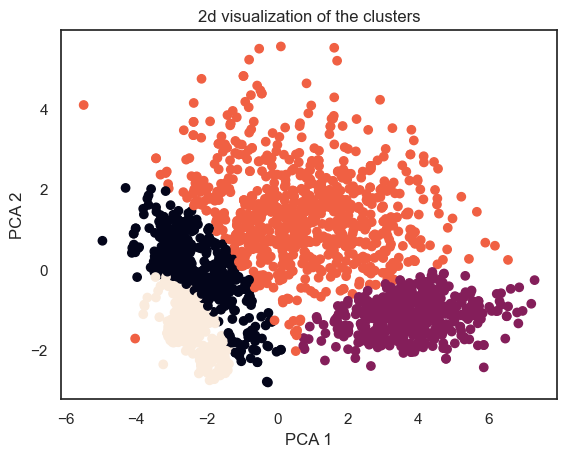

In [214]:
# Se extrae la primera componente principal (PC1)
# ":" → todas las filas
# "0" → primera columna (Componente Principal 1)
x = reduced_2_PCA[:, 0]

# Se extrae la segunda componente principal (PC2)
# "1" → segunda columna (Componente Principal 2)
y = reduced_2_PCA[:, 1]


# Se genera un gráfico de dispersión (scatter plot)
# donde:
# - x → valores del PCA 1
# - y → valores del PCA 2
# - c=PCA_2_pred → colorea cada punto según el cluster asignado por el GMM
plt.scatter(x, y, c=PCA_2_pred)

# Título del gráfico
plt.title("2d visualization of the clusters")

# Etiqueta del eje X (Primer Componente Principal)
plt.xlabel("PCA 1")

# Etiqueta del eje Y (Segundo Componente Principal)
plt.ylabel("PCA 2")


### Exercise 5 - Clustering and visualizing using 3 principal components (OPTIONAL) 


Text(0.5, 0.92, '3D projection of the clusters')

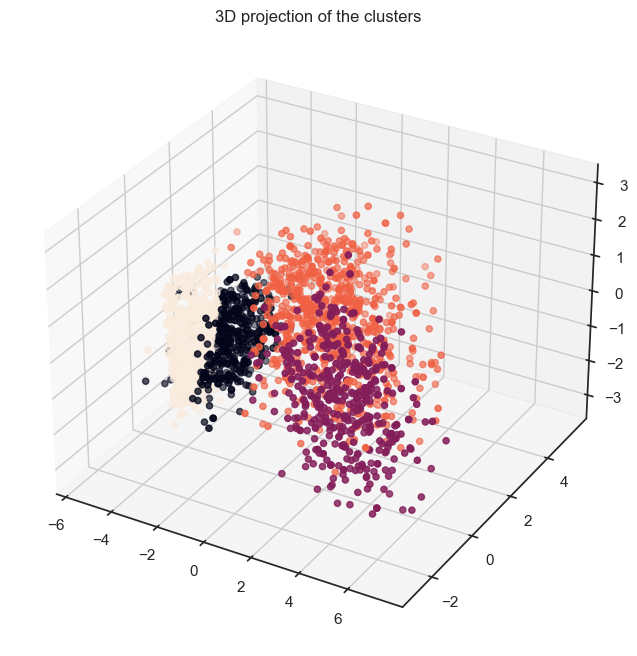

In [216]:
# PCA with n=3 and clustering
pca3 = PCA(n_components=3)
reduced_3_PCA = pca3.fit(X).transform(X)
mod = GaussianMixture(n_components=4, random_state=0)
PCA_3_pred = mod.fit(reduced_3_PCA).predict(reduced_3_PCA)

# plotting
reduced_3_PCA = pd.DataFrame(reduced_3_PCA, columns=(['PCA 1', 'PCA 2', 'PCA 3']))
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(reduced_3_PCA['PCA 1'],reduced_3_PCA['PCA 2'],reduced_3_PCA['PCA 3'], c=PCA_3_pred)
ax.set_title("3D projection of the clusters")

<details>
    <summary>Click here for Solution</summary>

```python
# PCA with n=3 and clustering
pca3 = PCA(n_components=3)
reduced_3_PCA = pca3.fit(X).transform(X)
mod = GaussianMixture(n_components=4, random_state=0)
PCA_3_pred = mod.fit(reduced_3_PCA).predict(reduced_3_PCA)

# plotting
reduced_3_PCA = pd.DataFrame(reduced_3_PCA, columns=(['PCA 1', 'PCA 2', 'PCA 3']))
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(reduced_3_PCA['PCA 1'],reduced_3_PCA['PCA 2'],reduced_3_PCA['PCA 3'], c=PCA_3_pred)
ax.set_title("3D projection of the clusters")
```

</details>


[Roxanne Li](https://www.linkedin.com/in/roxanne-li/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork821-2023-01-01) is a Data Science intern at IBM Skills Network, entering level-5 study in the Mathematics & Statistics undergraduate Coop program at McMaster University.


In [224]:
# =========================================
# PCA con 3 componentes y clustering GMM
# =========================================

# Se crea el modelo PCA reduciendo a 3 dimensiones
pca3 = PCA(n_components=3)

# Se ajusta el PCA a los datos estandarizados X
# y se transforman al nuevo espacio de 3 componentes
reduced_3_PCA = pca3.fit(X).transform(X)


# =========================================
# Aplicación de GMM
# =========================================

# Se crea un modelo de Mezcla Gaussiana con 4 clusters
mod = GaussianMixture(n_components=4, random_state=0)

# Se ajusta el modelo a los datos en 3D
# y se predicen las etiquetas de cluster
PCA_3_pred = mod.fit(reduced_3_PCA).predict(reduced_3_PCA)


# =========================================
# Visualización en 3D
# =========================================

# Convertimos el arreglo en DataFrame para usar nombres de columnas
reduced_3_PCA = pd.DataFrame(
    reduced_3_PCA,
    columns=['PCA 1', 'PCA 2', 'PCA 3']
)


# Se crea la figura
fig = plt.figure(figsize=(10,8))

# Se añade un eje 3D
ax = fig.add_subplot(111, projection="3d")

# Gráfico de dispersión en 3D
# c=PCA_3_pred colorea los puntos según el cluster asignado
ax.scatter(
    reduced_3_PCA['PCA 1'],
    reduced_3_PCA['PCA 2'],
    reduced_3_PCA['PCA 3'],
    c=PCA_3_pred
)

ax.set_title("3D projection of the clusters")


<IPython.core.display.Javascript object>

Text(0.5, 0.92, '3D projection of the clusters')

In [226]:
import plotly.express as px
import pandas as pd

# Convertimos a DataFrame
df_3d = pd.DataFrame(
    reduced_3_PCA,
    columns=['PCA 1', 'PCA 2', 'PCA 3']
)

# Agregamos las etiquetas del cluster
df_3d["Cluster"] = PCA_3_pred.astype(str)

# Creamos gráfica 3D interactiva
fig = px.scatter_3d(
    df_3d,
    x="PCA 1",
    y="PCA 2",
    z="PCA 3",
    color="Cluster",
    title="3D Interactive Projection of GMM Clusters"
)

fig.show()
